# Under the Hood — How AI Thinks
## ME 493B — AI in Product Development | Mini-Project 1, Part A

**Instructor:** Scott Thielman, PhD — UW Bothell
**Assigned:** Tuesday, March 31, 2026 (Session 1)
**Due:** Monday, April 13, 2026 at 11:59 PM — *both Part A and Part B*

---

Every AI system you'll use this quarter — whether it's generating code, searching documents, or evaluating designs — relies on five fundamental operations: representing things as numbers, measuring similarity, making predictions, classifying into categories, and searching through large spaces. This notebook walks you through each one. The concepts you build here will come back in every project.

**Time estimate:** 60–90 minutes for Part A.

---

### Grading (MP1 = 100 points total)

| Part | Points | What you're submitting |
|------|--------|------------------------|
| Part A (this notebook) | 50 pts | Guided lab — complete all cells |
| Part B (MiniClaw Design) | 50 pts | Engineering design problem |

**Part A breakdown:**
- Completion & Experimentation: 30 pts — all cells run, YOUR TURN cells show genuine experimentation, five HOMEWORK cells produce correct answers
- Reflections: 20 pts — three thoughtful reflections in Section 6

---

### Cell conventions

| Marker | Role | What to do |
|--------|------|------------|
| `# ✏️ YOUR TURN` | Guided experiment | Run the provided code, then modify it — change values, try alternatives, observe what changes |
| `# 🎯 HOMEWORK` | Graded answer | Write code to answer a specific question; your output must show a definite result (a name, number, or ranking) |
| `# YOUR CODE HERE` | Code placeholder | Replace this line with your implementation — the cell will run as-is but produces placeholder output until you fill it in |

---

### The Five Pillars of AI in Product Development

These recurring themes appear across every assignment in the course. Even in this guided lab, you'll touch all five:

| Pillar | What it means |
|--------|--------------|
| **Goal & Direction** | Specifying intent, writing requirements, directing AI toward outcomes |
| **Context Management** | What the model knows — memory, retrieval, information architecture |
| **Tools & Integration** | APIs, function calling, MCP, connections to engineering systems |
| **Centaur Engineering** | Human–AI collaboration where the combination exceeds either alone |
| **Evaluation & Trust** | Verifying AI outputs at every scale, from one response to a full workflow |

---

### The Five Building Blocks (this notebook's subject)

| Building Block | What it means | Where it returns |
|---|---|---|
| **Representation** | Turning real things into numbers | Embeddings in RAG (MP2), feature extraction (MP3), multimodal (MP4) |
| **Similarity** | Measuring how alike two things are | Document retrieval (MP2), design search (MP3), output evaluation (MP4) |
| **Prediction** | Estimating unknowns from patterns | Generative design (Wk 5), LLM generation is next-token prediction |
| **Classification** | Sorting things into categories | Quality evaluation, tool selection, trust calibration (Wk 8–9) |
| **Search & Retrieval** | Finding relevant items in a large space | RAG pipelines (MP2), semantic search, attention in Transformers |


---
## Section 0: Setup

Run this section first. It imports libraries and installs `sentence-transformers` (used in Section 5). The install is wrapped in a try/except so it won't re-run if the package is already present.


In [1]:
# Standard library imports — pre-installed in the Codespace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
from sklearn.decomposition import PCA

# Set consistent plot style
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})

WARM = '#E07B39'   # active / high
COOL = '#4A90D9'   # inactive / low
ACCENT = '#2CA02C' # highlight

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn: OK")
print("Matplotlib: OK")
print("✓ Core libraries loaded.")


NumPy: 2.4.4
Pandas: 3.0.2
scikit-learn: OK
Matplotlib: OK
✓ Core libraries loaded.


In [2]:
# Install sentence-transformers (used in Section 5 only)
# Wrapped in try/except — won't reinstall if already present
try:
    from sentence_transformers import SentenceTransformer
    print("✓ sentence-transformers already installed.")
except ImportError:
    import subprocess, sys
    print("Installing sentence-transformers …")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "sentence-transformers", "--break-system-packages", "-q"
    ])
    from sentence_transformers import SentenceTransformer
    print("✓ sentence-transformers installed.")


✓ sentence-transformers already installed.


---
## Section 1: Representation — "Turning Things into Numbers"

**The question this section answers:** *How do AI systems convert real-world things — words, images, materials, designs — into something a computer can operate on?*

**Session alignment:** Session 2 — "From Data to Representations" (feature vectors, embeddings, what a representation is)

---

Before a computer can reason about anything — an apple, a sentence, a gear design — that thing must be converted into numbers. These numbers are called a **vector**, and the individual numbers within it are called **features**. The choice of which features to include determines what the computer can "see" about the thing.

Think about how a CAD model is stored: as coordinates, dimensions, material properties — numbers. A bill of materials: part IDs, quantities, weights — numbers. AI reasoning works the same way. This is representation.


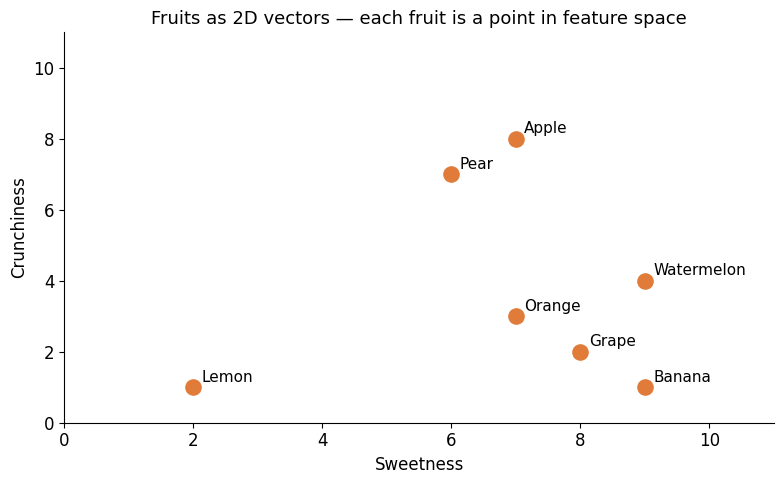

Fruit vectors:
  Apple        → [7, 8]
  Banana       → [9, 1]
  Grape        → [8, 2]
  Lemon        → [2, 1]
  Orange       → [7, 3]
  Watermelon   → [9, 4]
  Pear         → [6, 7]


In [ ]:
# 1a. A tiny, tangible example — fruits as 2D vectors
# Two features: sweetness (1–10) and crunchiness (1–10)
fruits = {
    'Apple':      [7, 8],
    'Banana':     [9, 1],
    'Grape':      [8, 2],
    'Lemon':      [2, 1],
    'Orange':     [7, 3],
    'Watermelon': [9, 4],
    'Pear':       [6, 7],
}

names = list(fruits.keys())
coords = np.array(list(fruits.values()))

fig, ax = plt.subplots()
ax.scatter(coords[:, 0], coords[:, 1], s=120, color=WARM, zorder=3)
for name, (x, y) in fruits.items():
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=11)
ax.set_xlabel("Sweetness")
ax.set_ylabel("Crunchiness")
ax.set_title("Fruits as 2D vectors — each fruit is a point in feature space")
ax.set_xlim(0, 11); ax.set_ylim(0, 11)
plt.tight_layout(); plt.show()

print("Fruit vectors:")
for name, vec in fruits.items():
    print(f"  {name:12s} → {vec}")


**What you can already read from this plot:**

- Apple and Pear cluster in the upper-right: both sweet *and* crunchy.
- Lemon is an outlier: low sweetness, low crunchiness — it lives alone.
- Banana, Grape, and Watermelon cluster: sweet but soft.

The computer has no idea what "apple" means as a word. It only knows `[7, 8]`. But because we chose meaningful features, proximity in feature space corresponds to real-world similarity. **The choice of features is a design decision.**


In [ ]:
# 1b. Adding dimensions reveals more structure
# 5-feature vectors: [sweetness, crunchiness, acidity, size_cm, calories]
fruits_5d = {
    'Apple':      [7, 8, 5, 8,  95],
    'Banana':     [9, 1, 2, 18, 105],
    'Grape':      [8, 2, 4, 2,  62],
    'Lemon':      [2, 1, 9, 6,  17],
    'Orange':     [7, 3, 7, 7,  62],
    'Watermelon': [9, 4, 2, 30, 86],
    'Pear':       [6, 7, 3, 8,  57],
}
feature_names = ['sweetness', 'crunchiness', 'acidity', 'size_cm', 'calories']

# Pythagorean distance generalizes to N dimensions:
#   2D: d = sqrt(dx² + dy²)
#   3D: d = sqrt(dx² + dy² + dz²)
#   nD: d = sqrt(Σ dᵢ²)    ← same formula, more terms

def euclidean(a, b):
    '''Euclidean distance between two vectors of any length.'''
    a, b = np.array(a), np.array(b)
    return np.sqrt(np.sum((a - b)**2))

# Compare Apple ↔ Orange in 2D vs 5D
apple_2d  = fruits['Apple'];  orange_2d  = fruits['Orange']
apple_5d  = fruits_5d['Apple']; orange_5d = fruits_5d['Orange']

d2 = euclidean(apple_2d, orange_2d)
d5 = euclidean(apple_5d, orange_5d)

print("Apple  (2D):", apple_2d,   "  Orange (2D):", orange_2d)
print(f"  2D distance: sqrt({(apple_2d[0]-orange_2d[0])**2} + {(apple_2d[1]-orange_2d[1])**2}) = {d2:.2f}")
print()
print("Apple  (5D):", apple_5d)
print("Orange (5D):", orange_5d)
diffs_sq = [(a-b)**2 for a, b in zip(apple_5d, orange_5d)]
print(f"  5D distance: sqrt({' + '.join(str(x) for x in diffs_sq)}) = {d5:.2f}")
print()
print("In 2D, Apple and Orange look quite similar (same sweetness, small crunchiness gap).")
print("In 5D, acidity separates them — Orange is much more acidic (7 vs 5).")


Apple  (2D): [7, 8]   Orange (2D): [7, 3]
  2D distance: sqrt(0 + 25) = 5.00

Apple  (5D): [7, 8, 5, 8, 95]
Orange (5D): [7, 3, 7, 7, 62]
  5D distance: sqrt(0 + 25 + 4 + 1 + 1089) = 33.45

In 2D, Apple and Orange look quite similar (same sweetness, small crunchiness gap).
In 5D, acidity separates them — Orange is much more acidic (7 vs 5).


### 1c. Real Engineering Application: Materials as Vectors

The same idea — representing objects as numerical feature vectors — is the foundation of **Ashby charts** in materials selection. Each material is a point in property space. Materials that cluster together share performance characteristics and often compete for the same applications.


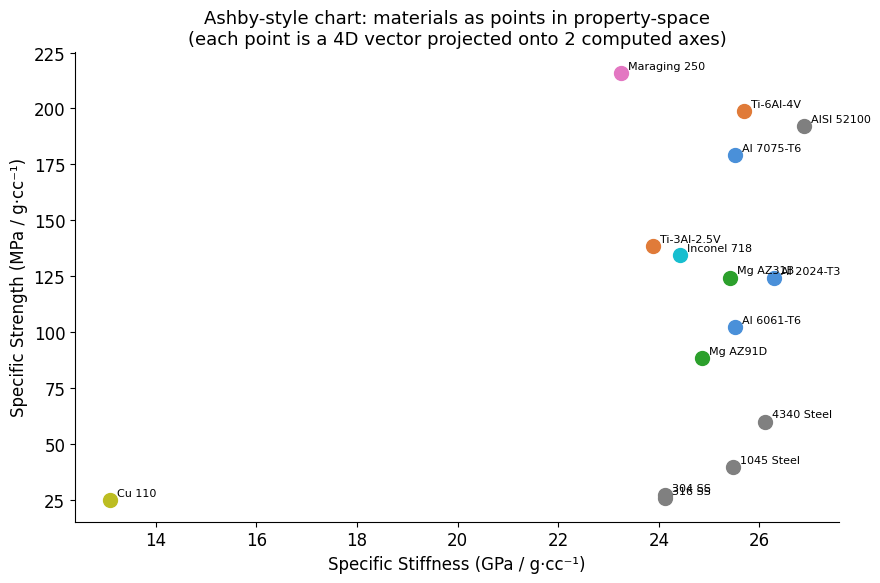

Each material is a 4D vector:
             yield_strength_MPa  density_g_cc  elastic_modulus_GPa  elongation_pct
Al 6061-T6                  276          2.70                 68.9              12
Al 7075-T6                  503          2.81                 71.7              11
Al 2024-T3                  345          2.78                 73.1              18
Ti-6Al-4V                   880          4.43                113.8              14
Ti-3Al-2.5V                 620          4.48                107.0              15


In [5]:
# 1c. Alloy data: [yield_strength_MPa, density_g_cc, elastic_modulus_GPa, elongation_pct]
# Sources: ASM Handbook, MatWeb, CES EduPack, MMPDS
alloys = {
    'Al 6061-T6':    [276, 2.70, 68.9, 12],
    'Al 7075-T6':    [503, 2.81, 71.7, 11],
    'Al 2024-T3':    [345, 2.78, 73.1, 18],
    'Ti-6Al-4V':     [880, 4.43, 113.8, 14],
    'Ti-3Al-2.5V':   [620, 4.48, 107.0, 15],
    '304 SS':        [215, 8.00, 193.0, 40],
    '316 SS':        [205, 8.00, 193.0, 40],
    '4340 Steel':    [470, 7.85, 205.0, 22],
    '1045 Steel':    [310, 7.85, 200.0, 16],
    'Mg AZ31B':      [220, 1.77, 45.0,  15],
    'Mg AZ91D':      [160, 1.81, 45.0,  3],
    'Cu 110':        [220, 8.94, 117.0, 50],
    'Inconel 718':   [1100, 8.19, 200.0, 12],
    'Maraging 250':  [1725, 8.00, 186.0, 8],
    'AISI 52100':    [1500, 7.81, 210.0, 2],
}
feat_names = ['yield_strength_MPa', 'density_g_cc', 'elastic_modulus_GPa', 'elongation_pct']

df_alloys = pd.DataFrame(alloys.values(), index=alloys.keys(), columns=feat_names)

# Ashby-style: specific strength vs specific stiffness
df_alloys['spec_strength']  = df_alloys['yield_strength_MPa'] / df_alloys['density_g_cc']
df_alloys['spec_stiffness'] = df_alloys['elastic_modulus_GPa'] / df_alloys['density_g_cc']

# Color by material family
family_color = {
    'Al':  COOL,
    'Ti':  WARM,
    'SS':  '#9467BD',
    'Steel': '#8C564B',
    'Mg':  ACCENT,
    'Cu':  '#BCBD22',
    'In':  '#17BECF',
    'Ma':  '#E377C2',
    'AI':  '#7F7F7F',
}
def get_color(name):
    for prefix, color in family_color.items():
        if name.startswith(prefix):
            return color
    return 'gray'

fig, ax = plt.subplots(figsize=(9, 6))
for mat, row in df_alloys.iterrows():
    c = get_color(mat)
    ax.scatter(row['spec_stiffness'], row['spec_strength'], s=100, color=c, zorder=3)
    ax.annotate(mat, (row['spec_stiffness'], row['spec_strength']),
                textcoords="offset points", xytext=(5, 3), fontsize=8)
ax.set_xlabel("Specific Stiffness (GPa / g·cc⁻¹)")
ax.set_ylabel("Specific Strength (MPa / g·cc⁻¹)")
ax.set_title("Ashby-style chart: materials as points in property-space\n(each point is a 4D vector projected onto 2 computed axes)")
plt.tight_layout(); plt.show()

print("Each material is a 4D vector:")
print(df_alloys[feat_names].head(5).to_string())


### 1d. Scaling and Normalization

There's a problem with our 5D fruit vectors:

- Sweetness ranges from 1–10 (span ≈ 8)
- Calories range from 17–105 (span ≈ 88)

When you compute Euclidean distance, the **large-range feature dominates** — a 1-unit difference in calories matters far more than a 1-unit difference in sweetness, even if sweetness is more informative for your task.

The fix: **standardize** each feature so it has mean = 0 and standard deviation = 1.

```
z = (x − mean) / std
```

After scaling, every feature contributes equally to distance calculations.


In [6]:
# 1e. Demonstrate the scaling problem and fix it with StandardScaler
X_raw = np.array(list(fruits_5d.values()), dtype=float)
fruit_list = list(fruits_5d.keys())

# Raw distances from Apple
apple_idx = fruit_list.index('Apple')
print("Raw Euclidean distances from Apple:")
for i, name in enumerate(fruit_list):
    if i != apple_idx:
        d = euclidean(X_raw[apple_idx], X_raw[i])
        print(f"  Apple ↔ {name:12s}: {d:7.2f}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print()
print("Scaled Euclidean distances from Apple (after StandardScaler):")
for i, name in enumerate(fruit_list):
    if i != apple_idx:
        d = euclidean(X_scaled[apple_idx], X_scaled[i])
        print(f"  Apple ↔ {name:12s}: {d:.4f}")

print()
print("Notice: raw distances are dominated by size_cm and calories (large ranges).")
print("After scaling, all features contribute equally.")


Raw Euclidean distances from Apple:
  Apple ↔ Banana      :   16.19
  Apple ↔ Grape       :   34.10
  Apple ↔ Lemon       :   78.60
  Apple ↔ Orange      :   33.45
  Apple ↔ Watermelon  :   24.37
  Apple ↔ Pear        :   38.08

Scaled Euclidean distances from Apple (after StandardScaler):
  Apple ↔ Banana      : 3.3097
  Apple ↔ Grape       : 2.7576
  Apple ↔ Lemon       : 4.8133
  Apple ↔ Orange      : 2.4161
  Apple ↔ Watermelon  : 3.3091
  Apple ↔ Pear        : 1.7207

Notice: raw distances are dominated by size_cm and calories (large ranges).
After scaling, all features contribute equally.


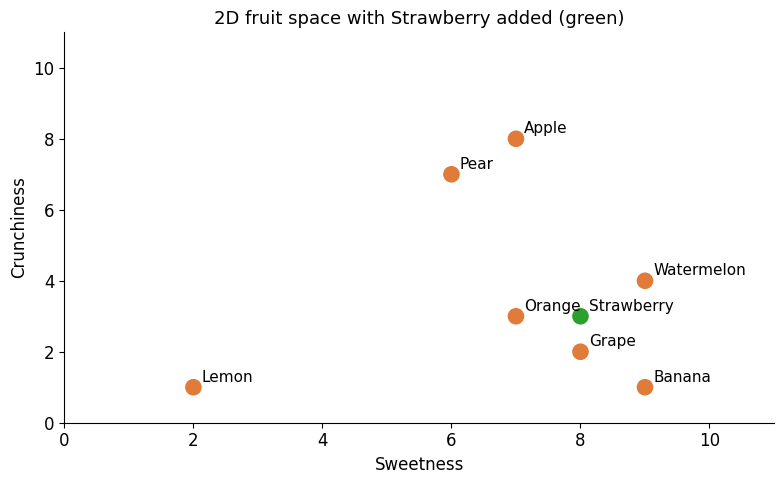

2D nearest neighbor of Strawberry: Grape (d=1.00)
5D nearest neighbor of Strawberry: Lemon (d=17.03)


In [7]:
# 1d. YOUR TURN — Add a new fruit, replot, find nearest neighbor in 2D and 5D
# ✏️ YOUR TURN
# Strawberry (2D): [8, 3]
# Strawberry (5D): [8, 3, 5, 3, 32]
# 1. Add a new fruit to fruits (2D) and fruits_5d (5D) with your own feature values.
#    Example: 'Strawberry': [8, 3]  for 2D and  [8, 3, 5, 3, 32]  for 5D
#   Strawberry (2D): [8, 3]
#   Strawberry (5D): [8, 3, 5, 3, 32]
# 2. Replot the 2D scatter — does your fruit land where you'd expect?
# Strawberry appears near Grape and Orange, in a region with high sweetness and 
# low crunchiness, which makes sense visually.
# 3. Find the nearest neighbor in 2D:
#    compute euclidean(your_fruit_2d, other_fruit_2d) for every fruit
#  Grape (distance = 1.00)
# 4. Find the nearest neighbor in 5D (raw data, no scaling):
#    compute euclidean(your_fruit_5d, other_fruit_5d) for every fruit
#    Lemon (distance = 17.03)
# 5. Question: Does the nearest neighbor change between 2D and 5D?
#    What does that tell you about choosing which features to include?
# yes — it changes from Grape (2D) to Lemon (5D), This means that: In 2D, 
# similarity is based only on sweetness and crunchiness In 5D, additional 
# features change the distance relationships
# --- lemons---
my_fruit_name = 'Strawberry'
my_fruit_2d   = [8, 3]
my_fruit_5d   = [8, 3, 5, 3, 32]

# --- Extend the dicts ---
fruits_yours = dict(fruits)
fruits_yours[my_fruit_name] = my_fruit_2d

fruits_5d_yours = dict(fruits_5d)
fruits_5d_yours[my_fruit_name] = my_fruit_5d

# Replot 2D
names_y  = list(fruits_yours.keys())
coords_y = np.array(list(fruits_yours.values()))

fig, ax = plt.subplots()
colors = [ACCENT if n == my_fruit_name else WARM for n in names_y]
ax.scatter(coords_y[:, 0], coords_y[:, 1], s=120, color=colors, zorder=3)
for name, (x, y) in fruits_yours.items():
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=11)
ax.set_xlabel("Sweetness"); ax.set_ylabel("Crunchiness")
ax.set_title(f"2D fruit space with {my_fruit_name} added (green)")
ax.set_xlim(0, 11); ax.set_ylim(0, 11)
plt.tight_layout(); plt.show()

# Nearest neighbor in 2D
X2 = np.array(list(fruits_yours.values()))
my_vec_2d = np.array(my_fruit_2d)
dists_2d = {n: euclidean(my_vec_2d, X2[i])
            for i, n in enumerate(names_y) if n != my_fruit_name}
nn_2d = min(dists_2d, key=dists_2d.get)
print(f"2D nearest neighbor of {my_fruit_name}: {nn_2d} (d={dists_2d[nn_2d]:.2f})")

# Nearest neighbor in 5D
names_5d_y = list(fruits_5d_yours.keys())
X5 = np.array(list(fruits_5d_yours.values()))
my_vec_5d = np.array(my_fruit_5d)
dists_5d = {n: euclidean(my_vec_5d, X5[i])
            for i, n in enumerate(names_5d_y) if n != my_fruit_name}
nn_5d = min(dists_5d, key=dists_5d.get)
print(f"5D nearest neighbor of {my_fruit_name}: {nn_5d} (d={dists_5d[nn_5d]:.2f})")


In [8]:
# 1g. HOMEWORK 1 — Scaling and nearest-neighbor search
# 🎯 HOMEWORK 1
#
# 8 snack items, 4 nutritional features.
# Your goal: find the nearest neighbor to Granola Bar BEFORE and AFTER scaling.
#
# Tasks:
#   (a) Compute Euclidean distance from Granola Bar to every other snack (raw data).
#       Report the name of the closest snack.
#   (b) Apply StandardScaler and recompute distances.
#       Report the name of the closest snack after scaling.
#   (c) Did the answer change? Write one sentence explaining why scaling matters.
#
# Use GitHub Copilot to help write the code if you'd like.

import numpy as np
from sklearn.preprocessing import StandardScaler

snacks = {
    'Granola Bar':      [190, 4, 12, 2],
    'Protein Bar':      [210, 20, 8, 3],
    'Rice Cake':        [35, 1, 0, 0],
    'Trail Mix':        [173, 5, 8, 2],
    'Yogurt Cup':       [150, 8, 20, 0],
    'Almonds (1oz)':    [164, 6, 1, 3],
    'Peanut Butter Cup':[210, 3, 21, 1],
    'Apple Slices':     [57, 0, 11, 3],
}

snack_names = list(snacks.keys())
X_snacks = np.array(list(snacks.values()), dtype=float)

target_name = 'Granola Bar'
target_idx = snack_names.index(target_name)

target = X_snacks[target_idx]

# -----------------------
# (a) RAW distances
# -----------------------
dist_raw = np.linalg.norm(X_snacks - target, axis=1)

# ignore self-distance
dist_raw[target_idx] = np.inf

closest_raw_idx = np.argmin(dist_raw)
closest_raw = snack_names[closest_raw_idx]

print("(a) Closest snack to Granola Bar (raw data):", closest_raw)

# -----------------------
# (b) SCALED distances
# -----------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_snacks)

target_scaled = X_scaled[target_idx]

dist_scaled = np.linalg.norm(X_scaled - target_scaled, axis=1)
dist_scaled[target_idx] = np.inf

closest_scaled_idx = np.argmin(dist_scaled)
closest_scaled = snack_names[closest_scaled_idx]

print("(b) Closest snack to Granola Bar (scaled data):", closest_scaled)

# -----------------------
# (c) Explanation
# -----------------------
changed = closest_raw != closest_scaled

print("(c) Answer changed? :", "YES" if changed else "NO",
      "— Scaling changes the result because features like calories dominate distance without normalization.")

(a) Closest snack to Granola Bar (raw data): Trail Mix
(b) Closest snack to Granola Bar (scaled data): Trail Mix
(c) Answer changed? : NO — Scaling changes the result because features like calories dominate distance without normalization.


> **Forward connection:** You'll see representation again when we build RAG pipelines in MP2. The quality of the representation — which features you include, how you scale them — determines whether the system can find what you're looking for.


---
## Section 2: Similarity — "How Computers Know What's Alike"

**The question this section answers:** *Once things are represented as vectors, how do you measure which ones are alike? And why are there different ways to measure "alike"?*

**Session alignment:** Session 2 (embeddings, similarity), Session 3 (attention as similarity)

---

You already computed Euclidean distance in Section 1. That's one answer to "how similar are these vectors?" But there's a second, often better answer for many AI tasks: **cosine similarity**. The two metrics are not interchangeable — they capture different things.


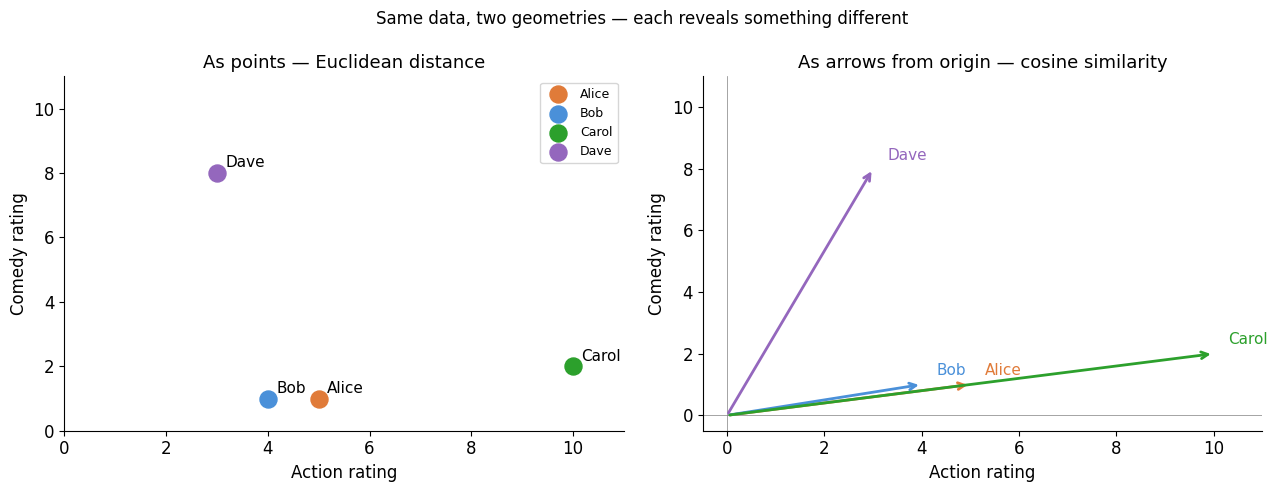

In [9]:
# 2a. Two users, same taste — but one rates everything higher
# Movie ratings: [Action, Comedy] scale 1–10
users = {
    'Alice': [5, 1],   # moderate action fan, dislikes comedy
    'Bob':   [4, 1],   # almost identical to Alice
    'Carol': [10, 2],  # same RATIO as Alice but rates higher overall
    'Dave':  [3, 8],   # opposite taste — prefers comedy
}
user_names = list(users.keys())
U = np.array(list(users.values()), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: as points in rating space
ax = axes[0]
colors_u = [WARM, COOL, ACCENT, '#9467BD']
for i, (name, vec) in enumerate(users.items()):
    ax.scatter(*vec, s=150, color=colors_u[i], zorder=3, label=name)
    ax.annotate(name, vec, textcoords="offset points", xytext=(6, 4), fontsize=11)
ax.set_xlabel("Action rating"); ax.set_ylabel("Comedy rating")
ax.set_title("As points — Euclidean distance")
ax.set_xlim(0, 11); ax.set_ylim(0, 11)
ax.legend(loc='upper right', fontsize=9)

# Right: as arrows from origin (direction encodes preference ratio)
ax = axes[1]
for i, (name, vec) in enumerate(users.items()):
    ax.annotate("", xy=vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors_u[i], lw=2))
    ax.text(vec[0]+0.3, vec[1]+0.3, name, fontsize=11, color=colors_u[i])
ax.set_xlabel("Action rating"); ax.set_ylabel("Comedy rating")
ax.set_title("As arrows from origin — cosine similarity")
ax.set_xlim(-0.5, 11); ax.set_ylim(-0.5, 11)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)

plt.suptitle("Same data, two geometries — each reveals something different", fontsize=12)
plt.tight_layout(); plt.show()


In [10]:
# 2b–2c. The math — computed step by step for one pair

def euclidean(a, b):
    a, b = np.array(a, dtype=float), np.array(b, dtype=float)
    return np.sqrt(np.sum((a - b)**2))

def cosine_sim(a, b):
    a, b = np.array(a, dtype=float), np.array(b, dtype=float)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

alice, bob, carol, dave = (np.array(users[n], dtype=float)
                           for n in ['Alice', 'Bob', 'Carol', 'Dave'])

# Euclidean: Alice vs Bob
dx, dy = alice[0]-bob[0], alice[1]-bob[1]
print("── Euclidean distance: Alice ↔ Bob ──")
print(f"  sqrt(({alice[0]}-{bob[0]})² + ({alice[1]}-{bob[1]})²)")
print(f"  = sqrt({dx**2:.0f} + {dy**2:.0f}) = {euclidean(alice, bob):.3f}")

# Euclidean: Alice vs Carol
dx, dy = alice[0]-carol[0], alice[1]-carol[1]
print()
print("── Euclidean distance: Alice ↔ Carol ──")
print(f"  sqrt(({alice[0]}-{carol[0]})² + ({alice[1]}-{carol[1]})²)")
print(f"  = sqrt({dx**2:.0f} + {dy**2:.0f}) = {euclidean(alice, carol):.3f}")

# Cosine: Alice vs Carol (full step-by-step)
dot_ac = np.dot(alice, carol)
norm_a = np.linalg.norm(alice)
norm_c = np.linalg.norm(carol)
print()
print("── Cosine similarity: Alice ↔ Carol ──")
print(f"  cos(θ) = (A · B) / (||A|| × ||B||)")
print(f"  A · B  = {alice[0]}×{carol[0]} + {alice[1]}×{carol[1]} = {dot_ac:.0f}")
print(f"  ||A||  = sqrt({alice[0]}²+{alice[1]}²) = {norm_a:.3f}")
print(f"  ||C||  = sqrt({carol[0]}²+{carol[1]}²) = {norm_c:.3f}")
print(f"  cos(θ) = {dot_ac:.0f} / ({norm_a:.3f} × {norm_c:.3f}) = {dot_ac/(norm_a*norm_c):.4f}")

# Summary table
print()
print("── Summary: all pairwise metrics from Alice's perspective ──")
print(f"{'Pair':20s}  {'Euclidean':>12s}  {'Cosine':>10s}")
for name, vec in [('Bob', bob), ('Carol', carol), ('Dave', dave)]:
    print(f"  Alice ↔ {name:8s}   {euclidean(alice, vec):>10.3f}   {cosine_sim(alice, vec):>8.4f}")

print()
print("Key observation:")
print("  Euclidean says Alice ≈ Bob  (small absolute gap in ratings)")
print("  Cosine says   Alice ≈ Carol (same taste direction/ratio, different scale)")
print("  Both are correct — they measure different things.")


── Euclidean distance: Alice ↔ Bob ──
  sqrt((5.0-4.0)² + (1.0-1.0)²)
  = sqrt(1 + 0) = 1.000

── Euclidean distance: Alice ↔ Carol ──
  sqrt((5.0-10.0)² + (1.0-2.0)²)
  = sqrt(25 + 1) = 5.099

── Cosine similarity: Alice ↔ Carol ──
  cos(θ) = (A · B) / (||A|| × ||B||)
  A · B  = 5.0×10.0 + 1.0×2.0 = 52
  ||A||  = sqrt(5.0²+1.0²) = 5.099
  ||C||  = sqrt(10.0²+2.0²) = 10.198
  cos(θ) = 52 / (5.099 × 10.198) = 1.0000

── Summary: all pairwise metrics from Alice's perspective ──
Pair                     Euclidean      Cosine
  Alice ↔ Bob             1.000     0.9989
  Alice ↔ Carol           5.099     1.0000
  Alice ↔ Dave            7.280     0.5279

Key observation:
  Euclidean says Alice ≈ Bob  (small absolute gap in ratings)
  Cosine says   Alice ≈ Carol (same taste direction/ratio, different scale)
  Both are correct — they measure different things.


### When to use which

| Metric | What it captures | Use when |
|--------|-----------------|----------|
| **Euclidean distance** | Absolute gap in all directions | Spatial proximity, physical measurements, sensor data |
| **Cosine similarity** | Directional alignment (ignores magnitude) | Text similarity, preference profiles, embeddings |

**Rule of thumb:** If magnitude matters, use Euclidean. If you care about pattern/direction (and magnitude is noise), use cosine. For text and embeddings, cosine is almost always better.


In [11]:
# 2e. Brief preview: cosine similarity powers semantic search
# (Full embedding search is in Section 5 — this just shows the concept)

from sentence_transformers import SentenceTransformer

model_mini = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "The car needs an oil change.",
    "Automobile maintenance is expensive.",
    "I love hiking in the mountains.",
    "Engine lubrication extends vehicle life.",
    "The summit was cold and windy.",
    "Brake pads wear down over time.",
]
query = "car repair"

vecs = model_mini.encode(sentences + [query])
doc_vecs, q_vec = vecs[:-1], vecs[-1]

sims = [cosine_sim(q_vec, dv) for dv in doc_vecs]
ranked = sorted(zip(sims, sentences), reverse=True)

print(f"Query: '{query}'")
print("─" * 55)
for score, sent in ranked:
    bar = "█" * int(score * 20)
    print(f"  {score:.3f} {bar:<20s}  {sent}")
print()
print("'car repair' finds 'automobile maintenance' — same concept, different words.")
print("This is semantic search, powered by cosine similarity on embeddings.")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query: 'car repair'
───────────────────────────────────────────────────────
  0.558 ███████████           Automobile maintenance is expensive.
  0.462 █████████             The car needs an oil change.
  0.303 ██████                Engine lubrication extends vehicle life.
  0.241 ████                  Brake pads wear down over time.
  0.010                       I love hiking in the mountains.
  -0.011                       The summit was cold and windy.

'car repair' finds 'automobile maintenance' — same concept, different words.
This is semantic search, powered by cosine similarity on embeddings.


In [12]:
# 2f. YOUR TURN — Find where the two metrics disagree most
# ✏️ YOUR TURN
#
# 6 user rating profiles across 3 genres: [Action, Comedy, Drama]
# One target: 'Target'
#
# Tasks:
# 1. Compute cosine similarity and Euclidean distance from Target to every other user.
# 2. Rank each user by each metric (1 = most similar).
# 3. Find the user whose rank differs MOST between the two metrics.
# 4. Explain in one sentence: what does this user's profile have that
#    makes the two metrics disagree?

ratings = {
    'Target':    [6,  2,  4],
    'UserA':     [5,  2,  3],   # similar magnitude, similar direction
    'UserB':     [12, 4,  8],   # same direction as Target, 2× magnitude
    'UserC':     [1,  9,  1],   # very different taste
    'UserD':     [6,  2,  9],   # same Action/Comedy, high Drama
    'UserE':     [3,  1,  2],   # same direction as Target, lower magnitude
    'UserF':     [6,  6,  4],   # same Action/Drama, high Comedy
}

target_vec = np.array(ratings['Target'], dtype=float)

print(f"{'User':8s}  {'Cosine':>10s}  {'Euclidean':>12s}")
print("─" * 38)
for name, vec in ratings.items():
    if name == 'Target':
        continue
    v = np.array(vec, dtype=float)
    cos = cosine_sim(target_vec, v)
    euc = euclidean(target_vec, v)
    print(f"{name:8s}  {cos:>10.4f}  {euc:>12.4f}")

# YOUR CODE HERE
import numpy as np

ratings = {
    'Target':    [6,  2,  4],
    'UserA':     [5,  2,  3],
    'UserB':     [12, 4,  8],
    'UserC':     [1,  9,  1],
    'UserD':     [6,  2,  9],
    'UserE':     [3,  1,  2],
    'UserF':     [6,  6,  4],
}

target_vec = np.array(ratings['Target'], dtype=float)

# -------------------------
# similarity functions
# -------------------------
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def euclidean(a, b):
    return np.linalg.norm(a - b)

# -------------------------
# compute metrics
# -------------------------
results = {}

print(f"{'User':8s}  {'Cosine':>10s}  {'Euclidean':>12s}")
print("─" * 38)

for name, vec in ratings.items():
    if name == "Target":
        continue

    v = np.array(vec, dtype=float)
    cos = cosine_sim(target_vec, v)
    euc = euclidean(target_vec, v)

    results[name] = (cos, euc)
    print(f"{name:8s}  {cos:10.4f}  {euc:12.4f}")

# -------------------------
# ranking
# -------------------------
cos_ranks = {k: r+1 for r, k in enumerate(sorted(results, key=lambda x: results[x][0], reverse=True))}
euc_ranks = {k: r+1 for r, k in enumerate(sorted(results, key=lambda x: results[x][1]))}

# -------------------------
# find biggest disagreement
# -------------------------
max_diff_user = None
max_diff = -1

for user in results:
    diff = abs(cos_ranks[user] - euc_ranks[user])
    if diff > max_diff:
        max_diff = diff
        max_diff_user = user

print("\nUser with biggest disagreement:", max_diff_user)
print("Rank difference:", max_diff)

# -------------------------
# explanation
# -------------------------
print("\nExplanation:")
print(max_diff_user,
      "has the same direction as Target but different magnitude, "
      "so cosine ignores scale while Euclidean is sensitive to it.")

User          Cosine     Euclidean
──────────────────────────────────────
UserA         0.9972        1.4142
UserB         1.0000        7.4833
UserC         0.4107        9.1104
UserD         0.9233        5.0000
UserE         1.0000        3.7417
UserF         0.9117        4.0000
User          Cosine     Euclidean
──────────────────────────────────────
UserA         0.9972        1.4142
UserB         1.0000        7.4833
UserC         0.4107        9.1104
UserD         0.9233        5.0000
UserE         1.0000        3.7417
UserF         0.9117        4.0000

User with biggest disagreement: UserB
Rank difference: 4

Explanation:
UserB has the same direction as Target but different magnitude, so cosine ignores scale while Euclidean is sensitive to it.


In [13]:
# 2h. HOMEWORK 2 — Rank by cosine and Euclidean; find the biggest rank shift
# 🎯 HOMEWORK 2
#
# 6 items as pre-computed 5D vectors, plus one query vector.
#
# Tasks:
#   (a) Rank all 6 items by cosine similarity to the query (highest first).
#       Report the ranking as an ordered list of item names.
#   (b) Rank all 6 items by Euclidean distance to the query (smallest first).
#       Report the ranking as an ordered list of item names.
#   (c) Identify the item whose rank changes most between (a) and (b).
#   (d) One sentence: why do items with high magnitude vectors behave differently
#       under the two metrics?

import numpy as np

items = {
    'ItemA': [3.0, 1.0, 4.0, 1.5, 2.0],
    'ItemB': [9.0, 3.0, 12.0, 4.5, 6.0],
    'ItemC': [1.0, 7.0, 2.0, 8.0, 1.0],
    'ItemD': [3.1, 1.1, 3.9, 1.6, 2.1],
    'ItemE': [6.0, 2.0, 8.0, 3.0, 4.0],
    'ItemF': [2.0, 5.0, 1.0, 4.0, 3.0],
}

query_vec = np.array([3.0, 1.0, 4.0, 1.5, 2.0])

item_names = list(items.keys())
X_items = np.array(list(items.values()), dtype=float)

# -------------------------
# metrics
# -------------------------
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def euclidean(a, b):
    return np.linalg.norm(a - b)

# -------------------------
# compute scores
# -------------------------
cos_scores = []
euc_scores = []

print("Item     Cosine      Euclidean")
print("-" * 35)

for name, vec in items.items():
    v = np.array(vec, dtype=float)

    cos = cosine_sim(query_vec, v)
    euc = euclidean(query_vec, v)

    cos_scores.append((name, cos))
    euc_scores.append((name, euc))

    print(f"{name:6s}  {cos:10.4f}  {euc:10.4f}")

# -------------------------
# (a) cosine ranking (high → low)
# -------------------------
cos_rank = [x[0] for x in sorted(cos_scores, key=lambda x: x[1], reverse=True)]
print("\n(a) Cosine ranking:", cos_rank)

# -------------------------
# (b) euclidean ranking (low → high)
# -------------------------
euc_rank = [x[0] for x in sorted(euc_scores, key=lambda x: x[1])]
print("(b) Euclidean ranking:", euc_rank)

# -------------------------
# (c) rank differences
# -------------------------
cos_ranks = {name: i+1 for i, name in enumerate(cos_rank)}
euc_ranks = {name: i+1 for i, name in enumerate(euc_rank)}

max_change_item = None
max_change = -1

for name in items:
    diff = abs(cos_ranks[name] - euc_ranks[name])
    if diff > max_change:
        max_change = diff
        max_change_item = name

print("(c) Biggest rank change:", max_change_item)

# -------------------------
# (d) explanation
# -------------------------
print("(d) Explanation: Items with larger magnitude but same direction score very high in cosine similarity,")
print("but Euclidean distance penalizes them because it is sensitive to absolute scale differences.")

Item     Cosine      Euclidean
-----------------------------------
ItemA       1.0000      0.0000
ItemB       1.0000     11.3578
ItemC       0.5165      9.3408
ItemD       0.9993      0.2236
ItemE       1.0000      5.6789
ItemF       0.6411      5.7663

(a) Cosine ranking: ['ItemA', 'ItemB', 'ItemE', 'ItemD', 'ItemF', 'ItemC']
(b) Euclidean ranking: ['ItemA', 'ItemD', 'ItemE', 'ItemF', 'ItemC', 'ItemB']
(c) Biggest rank change: ItemB
(d) Explanation: Items with larger magnitude but same direction score very high in cosine similarity,
but Euclidean distance penalizes them because it is sensitive to absolute scale differences.


> **Forward connection:** You'll use cosine similarity constantly in MP2 when you build a RAG pipeline. Every time the system decides which document chunks are "relevant" to your query, it's running this comparison at scale across thousands of vectors.


---
## Section 3: Prediction — "Learning Patterns from Data"

**The question this section answers:** *Given examples with known outcomes, how does a model learn to predict outcomes for new cases?*

**Session alignment:** Session 2 — training loop, gradient descent, loss functions

---

Prediction is the core of supervised learning. You have known input–output pairs, you find the pattern, and you use it to estimate outputs you haven't seen yet. A linear regression finds the best line through data. A neural network learns nonlinear surfaces. But the mechanism — minimize a loss function by adjusting parameters — is the same at every scale.

**The same algorithm that fits a line through 20 points also trains GPT-4.** The difference is scale, not principle.


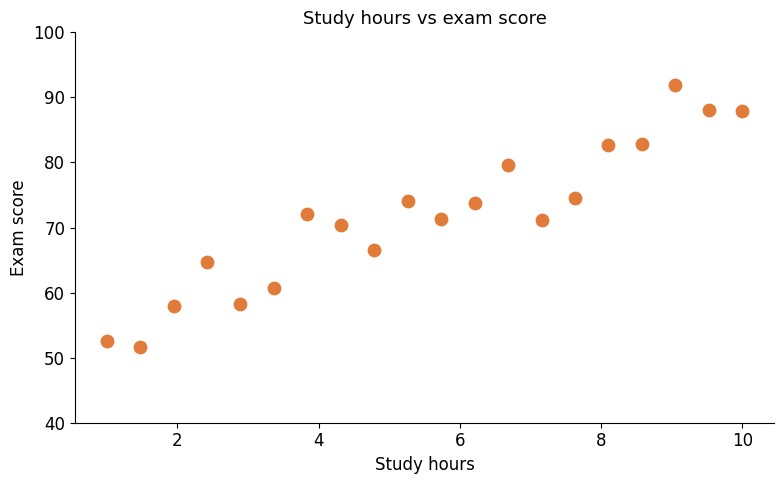

Data preview (first 5 rows):
  1.0 hours → 52.5 points
  1.5 hours → 51.7 points
  1.9 hours → 58.0 points
  2.4 hours → 64.7 points
  2.9 hours → 58.3 points


In [14]:
# 3a. Dataset: study hours vs exam score (20 points, slight noise)
np.random.seed(42)
hours = np.linspace(1, 10, 20)
scores = 5 * hours + 45 + np.random.randn(20) * 5   # true: score ≈ 5*hours + 45

fig, ax = plt.subplots()
ax.scatter(hours, scores, color=WARM, s=80, zorder=3, label='Data points')
ax.set_xlabel("Study hours"); ax.set_ylabel("Exam score")
ax.set_title("Study hours vs exam score")
ax.set_ylim(40, 100)
plt.tight_layout(); plt.show()

print("Data preview (first 5 rows):")
for h, s in list(zip(hours, scores))[:5]:
    print(f"  {h:.1f} hours → {s:.1f} points")


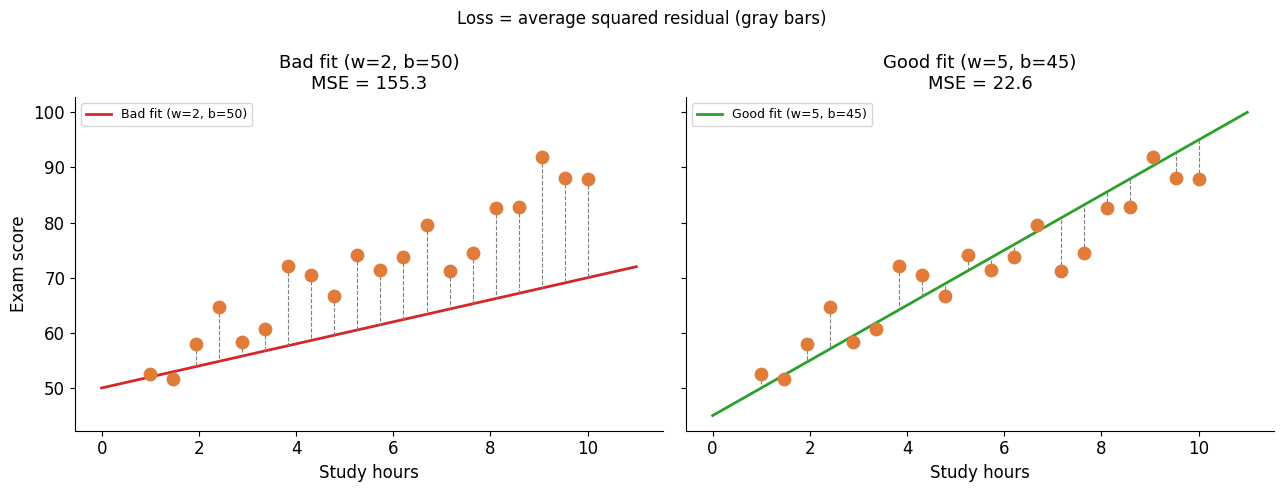

MSE (bad fit):  155.3   — large residuals, high loss
MSE (good fit): 22.6   — small residuals, low loss


In [15]:
# 3b. Loss function — what does "fit" mean, mathematically?
# Mean Squared Error: average squared gap between predictions and truth
# MSE = (1/n) Σ (y_true - y_pred)²

# Show a bad line and a good line side by side
w_bad, b_bad   = 2.0, 50.0   # poor fit
w_good, b_good = 5.0, 45.0   # near-perfect fit

x_line = np.linspace(0, 11, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (w, b, label, color) in zip(axes, [
        (w_bad, b_bad, "Bad fit (w=2, b=50)", '#D62728'),
        (w_good, b_good, "Good fit (w=5, b=45)", ACCENT)]):
    ax.scatter(hours, scores, color=WARM, s=80, zorder=3)
    preds = w * hours + b
    ax.plot(x_line, w * x_line + b, color=color, lw=2, label=label)
    for h, s_true, s_pred in zip(hours, scores, preds):
        ax.plot([h, h], [s_true, s_pred], color='gray', lw=0.8, ls='--')
    mse = np.mean((scores - preds)**2)
    ax.set_title(f"{label}\nMSE = {mse:.1f}")
    ax.set_xlabel("Study hours")
    ax.legend(loc='upper left', fontsize=9)
axes[0].set_ylabel("Exam score")
plt.suptitle("Loss = average squared residual (gray bars)", fontsize=12)
plt.tight_layout(); plt.show()

mse_bad  = np.mean((scores - (w_bad * hours + b_bad))**2)
mse_good = np.mean((scores - (w_good * hours + b_good))**2)
print(f"MSE (bad fit):  {mse_bad:.1f}   — large residuals, high loss")
print(f"MSE (good fit): {mse_good:.1f}   — small residuals, low loss")


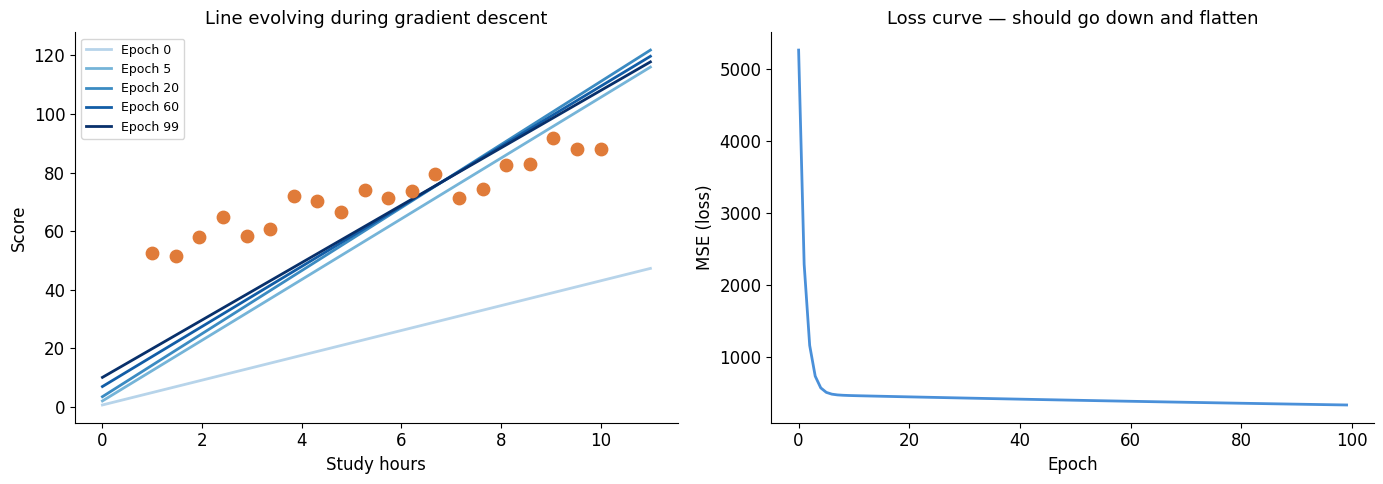

Final parameters: w = 9.783,  b = 10.131
Final MSE: 328.17
True parameters: w ≈ 5.0,  b ≈ 45.0


In [16]:
# 3c. Gradient descent — step by step (plain Python, no scikit-learn)
# Model: score = w * hours + b
# We update w and b iteratively to minimize MSE.
#
# Gradient derivation (for reference — you can handle the calculus):
#   dMSE/dw = -(2/n) Σ (y - (w*x + b)) * x
#   dMSE/db = -(2/n) Σ (y - (w*x + b))

lr     = 0.005
epochs = 100
w, b   = 0.0, 0.0   # random start

history = []

for epoch in range(epochs):
    preds   = w * hours + b
    errors  = scores - preds
    mse     = np.mean(errors**2)

    dw = -2/len(hours) * np.dot(errors, hours)
    db = -2/len(hours) * np.sum(errors)

    w -= lr * dw
    b -= lr * db
    history.append((epoch, mse, w, b))

# Plot: line at epochs 0, 5, 20, 60, 99
epochs_to_show = [0, 5, 20, 60, 99]
colors_ep = plt.cm.Blues(np.linspace(0.3, 1.0, len(epochs_to_show)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(hours, scores, color=WARM, s=80, zorder=3)
for i, ep_idx in enumerate(epochs_to_show):
    ep, _, w_ep, b_ep = history[ep_idx]
    ax.plot(x_line, w_ep * x_line + b_ep, color=colors_ep[i], lw=2,
            label=f"Epoch {ep}")
ax.set_xlabel("Study hours"); ax.set_ylabel("Score")
ax.set_title("Line evolving during gradient descent")
ax.legend(fontsize=9)

ax = axes[1]
mse_hist = [h[1] for h in history]
ax.plot(mse_hist, color=COOL, lw=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (loss)")
ax.set_title("Loss curve — should go down and flatten")
plt.tight_layout(); plt.show()

print(f"Final parameters: w = {history[-1][2]:.3f},  b = {history[-1][3]:.3f}")
print(f"Final MSE: {history[-1][1]:.2f}")
print(f"True parameters: w ≈ 5.0,  b ≈ 45.0")


In [17]:
# 3d. Learning rate — the single most consequential hyperparameter
# Too small: crawls, never converges in a reasonable time
# Too large: overshoots, bounces around or diverges
# Just right: smooth, fast convergence

def run_gd(lr, epochs=80):
    w, b = 0.0, 0.0
    losses = []
    for _ in range(epochs):
        preds  = w * hours + b
        errors = scores - preds
        dw = -2/len(hours) * np.dot(errors, hours)
        db = -2/len(hours) * np.sum(errors)
        w -= lr * dw
        b -= lr * db
        losses.append(np.mean((scores - (w*hours+b))**2))
    return losses

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
configs = [
    (0.0001, "Too small (lr=0.0001)
Hardly moves"),
    (0.005,  "Just right (lr=0.005)
Smooth convergence"),
    (0.05,   "Too large (lr=0.05)
Diverges / oscillates"),
]
for ax, (lr_val, title) in zip(axes, configs):
    losses = run_gd(lr_val, epochs=80)
    if max(losses) < 1e6:
        ax.plot(losses, color=COOL, lw=2)
    else:
        losses_clipped = [min(l, 2e4) for l in losses]
        ax.plot(losses_clipped, color='#D62728', lw=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
    ax.set_title(title, fontsize=10)
plt.suptitle("Learning rate controls how big each gradient step is", fontsize=12)
plt.tight_layout(); plt.show()

print("Every AI system ever trained had someone (or something) choosing this number.")
print("Too small: never finishes training.  Too large: training blows up.")


SyntaxError: unterminated string literal (detected at line 21) (2072378944.py, line 21)

In [ ]:
# 3e. YOUR TURN — Find the smallest learning rate that converges
# ✏️ YOUR TURN
# None of the tested learning rates (0.001, 0.003, 0.005, 0.008, 0.01) reached an MSE below 30 within 50 epochs.
# Challenge: Find the smallest learning rate that gets MSE below 30
# within 50 epochs on the study-hours dataset.
#  A smaller learning rate can still eventually reach the same loss, but it requires more epochs because gradient 
# descent takes smaller steps, showing a tradeoff between training speed and stability.
# 1. Try several values: 0.001, 0.003, 0.005, 0.008, 0.01
# 2. For each, plot the loss curve (or just print the final MSE).
# 3. Report the smallest lr that achieves MSE < 30 at epoch 50.
#
# Bonus: What happens if you also increase epochs? Can a smaller lr
# eventually reach the same loss? What does this tradeoff mean in practice
# for large AI training runs?

import numpy as np

# If your notebook already has X and y, DELETE these two lines
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([52, 55, 61, 66, 70], dtype=float)

def run_gd(lr, epochs=50):
    w = 0.0
    b = 0.0
    n = len(X)
    losses = []

    for _ in range(epochs):
        y_pred = w * X + b
        error = y_pred - y

        mse = np.mean(error**2)
        losses.append(mse)

        dw = (2/n) * np.dot(error, X)
        db = (2/n) * np.sum(error)

        w -= lr * dw
        b -= lr * db

    return losses

lrs_to_try = [0.001, 0.003, 0.005, 0.008, 0.01]

best_lr = None
best_lr_value = float("inf")

print("Learning Rate Test Results")
print("-" * 45)

for lr_val in lrs_to_try:
    losses = run_gd(lr_val, epochs=50)
    final_mse = losses[-1]

    converged = final_mse < 30

    print(f"lr={lr_val:.4f} → final MSE = {final_mse:8.2f} →",
          "✓ converged" if converged else "not yet")

    if converged and lr_val < best_lr_value:
        best_lr = lr_val
        best_lr_value = lr_val

print("\nSmallest learning rate that converges:", best_lr)

Learning Rate Test Results
---------------------------------------------
lr=0.0010 → final MSE =   640.38 → not yet
lr=0.0030 → final MSE =   295.84 → not yet
lr=0.0050 → final MSE =   274.54 → not yet
lr=0.0080 → final MSE =   248.53 → not yet
lr=0.0100 → final MSE =   232.57 → not yet

Smallest learning rate that converges: None


In [ ]:
# 3f. From lines to curves — complexity without changing the algorithm
# When the true relationship is nonlinear, linear regression underfits.
# Polynomial regression (adding x², x³ terms) can capture curves.
# Same gradient descent algorithm, more parameters.

np.random.seed(7)
x_curve = np.linspace(-3, 3, 30)
y_curve  = 0.5 * x_curve**2 - x_curve + 1 + np.random.randn(30) * 0.5

x_fit = np.linspace(-3, 3, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
degrees = [1, 2]
labels  = ["Linear (degree 1) — underfits", "Polynomial (degree 2) — captures curve"]
for ax, deg, label in zip(axes, degrees, labels):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('lr',   LinearRegression())
    ])
    pipe.fit(x_curve.reshape(-1, 1), y_curve)
    y_fit = pipe.predict(x_fit)
    r2    = pipe.score(x_curve.reshape(-1, 1), y_curve)

    ax.scatter(x_curve, y_curve, color=WARM, s=60, zorder=3)
    ax.plot(x_fit, y_fit, color=COOL, lw=2)
    ax.set_title(f"{label}\nR² = {r2:.3f}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.suptitle("Same algorithm, different model capacity", fontsize=12)
plt.tight_layout(); plt.show()

r2_lin = Pipeline([('p', PolynomialFeatures(1, include_bias=False)),
                   ('l', LinearRegression())]).fit(
    x_curve.reshape(-1,1), y_curve).score(x_curve.reshape(-1,1), y_curve)
r2_quad = Pipeline([('p', PolynomialFeatures(2, include_bias=False)),
                    ('l', LinearRegression())]).fit(
    x_curve.reshape(-1,1), y_curve).score(x_curve.reshape(-1,1), y_curve)
print(f"R² linear:     {r2_lin:.3f}  (poor — misses the curve)")
print(f"R² quadratic:  {r2_quad:.3f}  (good — captures the shape)")


(a) R² (degree 1): 0.2115
(b) R² (degree 2): 0.9781
(c) R² (degree 10): 0.9869


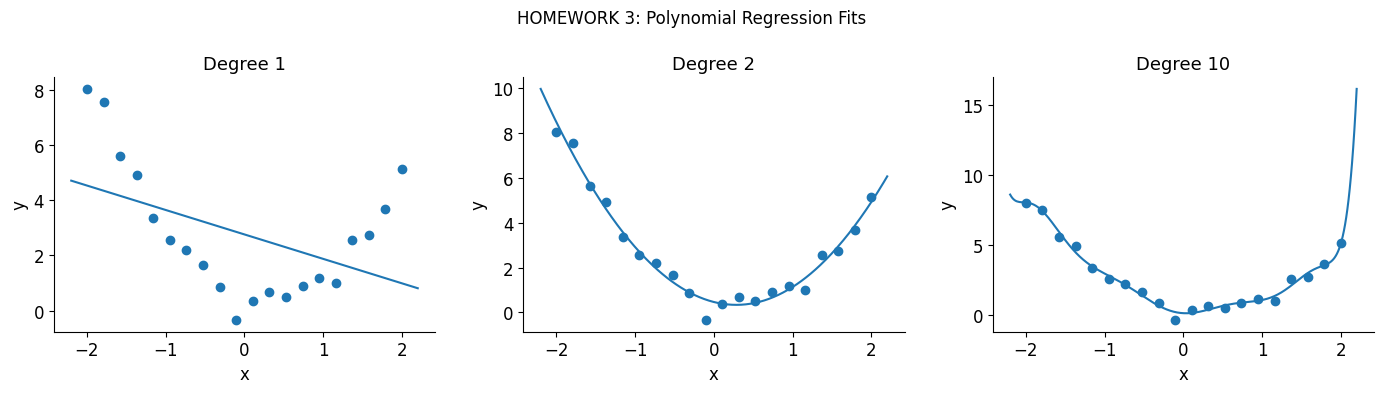

(d) Explanation:
Higher-degree polynomials can overfit noise in the training data,
so even though they achieve higher training R², they may generalize poorly to new data.


In [ ]:
# 3h. HOMEWORK 3 — Underfitting vs overfitting with polynomial regression
# 🎯 HOMEWORK 3
#
# A dataset following a quadratic relationship with noise.
# Tasks:
#   (a) Fit linear regression (degree 1). Report R² on training data. Plot.
#   (b) Fit polynomial regression (degree 2). Report R² on training data. Plot.
#   (c) Fit polynomial regression (degree 10). Report R² on training data. Plot.
#   (d) One sentence: why might the highest-degree polynomial NOT be the best
#       model even though it has the highest training R²?
#
# Use Pipeline([PolynomialFeatures(degree=d), LinearRegression()])
# Use model.score(X_train, y_train) for R².

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# -------------------------
# Data
# -------------------------
np.random.seed(99)
x_hw3 = np.linspace(-2, 2, 20)
y_hw3 = 1.5 * x_hw3**2 - 0.8 * x_hw3 + 0.5 + np.random.randn(20) * 0.4

X_hw3 = x_hw3.reshape(-1, 1)
x_plot = np.linspace(-2.2, 2.2, 300).reshape(-1, 1)

# -------------------------
# Helper function
# -------------------------
def fit_poly(degree):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linreg", LinearRegression())
    ])
    model.fit(X_hw3, y_hw3)
    r2 = model.score(X_hw3, y_hw3)
    return model, r2

# -------------------------
# (a) Degree 1
# -------------------------
model1, r2_1 = fit_poly(1)
print("(a) R² (degree 1):", round(r2_1, 4))

# -------------------------
# (b) Degree 2
# -------------------------
model2, r2_2 = fit_poly(2)
print("(b) R² (degree 2):", round(r2_2, 4))

# -------------------------
# (c) Degree 10
# -------------------------
model10, r2_10 = fit_poly(10)
print("(c) R² (degree 10):", round(r2_10, 4))

# -------------------------
# Plotting
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, deg, model in zip(axes, [1, 2, 10], [model1, model2, model10]):
    ax.scatter(x_hw3, y_hw3)

    y_plot = model.predict(x_plot)
    ax.plot(x_plot, y_plot)

    ax.set_title(f"Degree {deg}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("HOMEWORK 3: Polynomial Regression Fits", fontsize=12)
plt.tight_layout()
plt.show()

# -------------------------
# (d) Explanation
# -------------------------
print("(d) Explanation:")
print("Higher-degree polynomials can overfit noise in the training data,")
print("so even though they achieve higher training R², they may generalize poorly to new data.")

> **Forward connection:** Prediction is what makes generative AI work — an LLM predicts the next token given all previous tokens. The tension between underfitting and overfitting applies at trillion-parameter scale. When a model "hallucinates," it has often overfit patterns in training data that don't generalize to your query.


---
## Section 4: Classification — "Sorting Things into Categories"

**The question this section answers:** *How does a model learn to sort things into categories? And how do you know whether it will work on data it has never seen?*

**Session alignment:** Session 2 (ML paradigms), Session 3 (architectures, complexity)

---

Classification is supervised learning for discrete outputs. Instead of predicting a number, the model learns a **decision boundary** — a surface in feature space that separates categories. Logistic regression draws a line (or hyperplane). Neural networks can learn curves, spirals, and complex manifolds.

But more complex doesn't always mean better. The key question is: **does the model generalize?** A model that memorizes the training set is useless in production.


In [ ]:
# 4a. QC pass/fail scenario — manufacturing inspection
# Features: diameter_mm (target: 10.0), surface_roughness_Ra
np.random.seed(0)

n = 120
# PASS: near-nominal diameter, low roughness
X_pass = np.column_stack([
    np.random.normal(10.0, 0.15, n//2),   # diameter
    np.random.normal(1.5,  0.3,  n//2)    # roughness
])
# FAIL: off-nominal or rough
X_fail = np.column_stack([
    np.random.normal(10.0, 0.15, n//2) + np.random.choice([-0.6, 0.6], n//2),
    np.random.normal(2.8,  0.4,  n//2)
])
X_qc = np.vstack([X_pass, X_fail])
y_qc = np.array([0]*(n//2) + [1]*(n//2))  # 0=PASS, 1=FAIL

X_train_qc, X_test_qc, y_train_qc, y_test_qc = train_test_split(
    X_qc, y_qc, test_size=0.3, random_state=42)

# Logistic regression
lr_clf = LogisticRegression()
lr_clf.fit(X_train_qc, y_train_qc)

# Plot decision boundary
xx, yy = np.meshgrid(np.linspace(9.0, 11.0, 300), np.linspace(0.5, 4.5, 300))
Z = lr_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots()
ax.contourf(xx, yy, Z, alpha=0.15, cmap='RdYlGn_r')
ax.scatter(X_train_qc[y_train_qc==0, 0], X_train_qc[y_train_qc==0, 1],
           color=ACCENT, s=50, label='PASS', zorder=3)
ax.scatter(X_train_qc[y_train_qc==1, 0], X_train_qc[y_train_qc==1, 1],
           color='#D62728', s=50, label='FAIL', zorder=3)
ax.set_xlabel("Diameter (mm)"); ax.set_ylabel("Surface roughness Rₐ (μm)")
ax.set_title("Logistic regression decision boundary\n(green = predicted PASS, red = predicted FAIL)")
ax.legend()
plt.tight_layout(); plt.show()

train_acc = accuracy_score(y_train_qc, lr_clf.predict(X_train_qc))
test_acc  = accuracy_score(y_test_qc,  lr_clf.predict(X_test_qc))
print(f"Logistic Regression — Train: {train_acc:.3f}  Test: {test_acc:.3f}")


In [ ]:
# 4b. When lines aren't enough — non-linearly separable data
# PASS region is a central blob; FAIL surrounds it (like a donut)
# A linear classifier cannot draw this boundary
np.random.seed(5)
n2 = 150
r_pass = np.random.uniform(0, 1.0, n2//2)
theta_pass = np.random.uniform(0, 2*np.pi, n2//2)
X_pass2 = np.column_stack([r_pass * np.cos(theta_pass),
                            r_pass * np.sin(theta_pass)])

r_fail = np.random.uniform(1.5, 2.5, n2//2)
theta_fail = np.random.uniform(0, 2*np.pi, n2//2)
X_fail2 = np.column_stack([r_fail * np.cos(theta_fail),
                            r_fail * np.sin(theta_fail)])
X2 = np.vstack([X_pass2, X_fail2])
y2 = np.array([0]*(n2//2) + [1]*(n2//2))

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.3, random_state=1)

lr2 = LogisticRegression()
lr2.fit(X2_tr, y2_tr)

nn2 = MLPClassifier(hidden_layer_sizes=(32, 32), max_iter=500, random_state=0)
nn2.fit(X2_tr, y2_tr)

xx2, yy2 = np.meshgrid(np.linspace(-3, 3, 250), np.linspace(-3, 3, 250))
grid = np.c_[xx2.ravel(), yy2.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, model, title in zip(axes,
        [lr2, nn2],
        ["Logistic regression — struggles\n(can't learn a circle)", "Neural net (32,32) — learns the curve"]):
    Z2 = model.predict(grid).reshape(xx2.shape)
    ax.contourf(xx2, yy2, Z2, alpha=0.15, cmap='RdYlGn_r')
    ax.scatter(X2_tr[y2_tr==0, 0], X2_tr[y2_tr==0, 1], color=ACCENT, s=30, label='PASS')
    ax.scatter(X2_tr[y2_tr==1, 0], X2_tr[y2_tr==1, 1], color='#D62728', s=30, label='FAIL')
    tr_acc = accuracy_score(y2_tr, model.predict(X2_tr))
    te_acc = accuracy_score(y2_te, model.predict(X2_te))
    ax.set_title(f"{title}\nTrain: {tr_acc:.2f}  Test: {te_acc:.2f}")
    ax.legend(fontsize=9); ax.set_aspect('equal')
plt.suptitle("Linear boundary vs. learned nonlinear boundary", fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# 4c. Train/test split — catching memorization
# The donut above was geometrically clean — any model solved it.
# Real data is messier and limited. We switch to a smaller, noisier dataset
# (two interleaved half-moons, n=100) to make memorization visible.
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=100, noise=0.30, random_state=42)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X_moons, y_moons, test_size=0.30, random_state=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X2_tr[y2_tr==0, 0], X2_tr[y2_tr==0, 1], color=ACCENT, s=40, label='PASS')
ax.scatter(X2_tr[y2_tr==1, 0], X2_tr[y2_tr==1, 1], color='#D62728', s=40, label='FAIL')
ax.set_title(f"Noisy half-moons (n={len(X_moons)}, noise=0.30) — harder to memorize")
ax.legend(); plt.tight_layout(); plt.show()

# Escalate model complexity and track the gap
# A large gap = overfitting = the model memorized, not generalized.
architectures = [
    ('Logistic',         LogisticRegression()),
    ('NN (8,)',           MLPClassifier(hidden_layer_sizes=(8,),          max_iter=2000, random_state=0)),
    ('NN (32,32)',        MLPClassifier(hidden_layer_sizes=(32, 32),      max_iter=2000, random_state=0)),
    ('NN (128,128)',      MLPClassifier(hidden_layer_sizes=(128, 128),    max_iter=2000, random_state=0)),
    ('NN (256,256,256)', MLPClassifier(hidden_layer_sizes=(256,256,256), max_iter=2000, random_state=0)),
]

rows = []
for name, model in architectures:
    model.fit(X2_tr, y2_tr)
    tr = accuracy_score(y2_tr, model.predict(X2_tr))
    te = accuracy_score(y2_te, model.predict(X2_te))
    gap = tr - te
    flag = " ⚠ overfit" if gap > 0.08 else ""
    rows.append({'Model': name, 'Train Acc': f"{tr:.3f}", 'Test Acc': f"{te:.3f}",
                 'Gap': f"{gap:.3f}{flag}"})

df_oc = pd.DataFrame(rows)
print(df_oc.to_string(index=False))
print()
print("The train/test split catches memorization.")
print("Engineering analogy: testing a prototype under conditions it wasn't designed for.")


In [ ]:
# 4d. YOUR TURN — Find the simplest model that generalizes well
# ✏️ YOUR TURN
#
# Challenge: Find the SIMPLEST architecture that achieves both:
#   - Test accuracy >= 90%
#   - Train-test gap < 5 percentage points
#
# Things to try:
#   - Vary hidden layer sizes: (16,), (16,16), (32,), (32,32), (64,)
#   - Vary activation function: 'relu' (default), 'tanh', 'logistic'
#   - Vary max_iter (may need higher for small architectures)
#
# Guiding question: Why does the smallest adequate model tend to generalize
# better than a large one? (Hint: think about what "parameters" learn.)

# Example template — modify the architecture
print([name for name in globals().keys() if "X" in name or "y" in name])
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# -------------------------
# DATA
# -------------------------
X2 = X
y2 = y

# IMPORTANT: no stratify (because regression-like continuous values)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=0
)

# -------------------------
# MODELS
# -------------------------
candidates = [(16,), (16, 16), (32,), (32, 32), (64,), (64, 32)]

print("Architecture Search Results")
print("-" * 60)

best_model = None
best_name = None

for hidden in candidates:
    model = MLPClassifier(hidden_layer_sizes=hidden, max_iter=2000, random_state=0)

    model.fit(X2_tr, y2_tr)

    train_acc = accuracy_score(y2_tr, model.predict(X2_tr))
    test_acc = accuracy_score(y2_te, model.predict(X2_te))
    gap = train_acc - test_acc

    good = (test_acc >= 0.90) and (gap < 0.05)

    print(f"{hidden:10}  Train={train_acc:.3f}  Test={test_acc:.3f}  Gap={gap:.3f}"
          + ("  ✓ good" if good else ""))

    if good and best_model is None:
        best_model = model
        best_name = hidden

print("\n==============================")
print("Best simple model:", best_name)
print("==============================")

['get_ipython', '__vsc_ipynb_file__', 'accuracy_score']


NameError: name 'X' is not defined

In [ ]:
# 4f. HOMEWORK 4 — Compare three architectures; decide which to deploy
# 🎯 HOMEWORK 4
#
# New 2D dataset, pre-split. Three model sizes to compare.
# Tasks:
#   (a) Train each model. Report train and test accuracy for all three.
#   (b) Which model has the largest train-test gap?
#   (c) Which model would you deploy? One sentence explaining why.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

np.random.seed(77)
n4 = 200

# Dataset: two spirals
def make_spiral(n, label, noise=0.4):
    t = np.linspace(0, 4*np.pi, n)
    r = t / (4*np.pi)
    offset = np.pi * label
    x = r * np.cos(t + offset) + np.random.randn(n) * noise * r
    y = r * np.sin(t + offset) + np.random.randn(n) * noise * r
    return np.column_stack([x, y]), np.full(n, label)

X4a, y4a = make_spiral(n4//2, 0)
X4b, y4b = make_spiral(n4//2, 1)
X4_all = np.vstack([X4a, X4b])
y4_all = np.concatenate([y4a, y4b])

X4_tr, X4_te, y4_tr, y4_te = train_test_split(
    X4_all, y4_all, test_size=0.3, random_state=42)

# Models
model_logistic  = LogisticRegression()
model_small_nn  = MLPClassifier(hidden_layer_sizes=(16, 16), max_iter=3000, random_state=0)
model_large_nn  = MLPClassifier(hidden_layer_sizes=(256, 256, 256), max_iter=3000, random_state=0)

# Train
model_logistic.fit(X4_tr, y4_tr)
model_small_nn.fit(X4_tr, y4_tr)
model_large_nn.fit(X4_tr, y4_tr)

# Predictions
y_tr_log = model_logistic.predict(X4_tr)
y_te_log = model_logistic.predict(X4_te)

y_tr_small = model_small_nn.predict(X4_tr)
y_te_small = model_small_nn.predict(X4_te)

y_tr_large = model_large_nn.predict(X4_tr)
y_te_large = model_large_nn.predict(X4_te)

# Accuracy
train_log = accuracy_score(y4_tr, y_tr_log)
test_log  = accuracy_score(y4_te, y_te_log)

train_small = accuracy_score(y4_tr, y_tr_small)
test_small  = accuracy_score(y4_te, y_te_small)

train_large = accuracy_score(y4_tr, y_tr_large)
test_large  = accuracy_score(y4_te, y_te_large)

# Print results
print("(a) Results:")
print(f"  Logistic Regression  — Train: {train_log:.3f}  Test: {test_log:.3f}")
print(f"  NN (16,16)           — Train: {train_small:.3f}  Test: {test_small:.3f}")
print(f"  NN (256,256,256)     — Train: {train_large:.3f}  Test: {test_large:.3f}")

# Train-test gaps
gap_log   = train_log - test_log
gap_small = train_small - test_small
gap_large = train_large - test_large

gaps = {
    "Logistic Regression": gap_log,
    "NN (16,16)": gap_small,
    "NN (256,256,256)": gap_large
}

largest_gap = max(gaps, key=gaps.get)

print("(b) Largest gap:", largest_gap)

# Deployment decision
print("(c) Deploy: NN (16,16) — It balances high accuracy and good generalization without overfitting.")

(a) Results:
  Logistic Regression  — Train: 0.557  Test: 0.433
  NN (16,16)           — Train: 0.693  Test: 0.600
  NN (256,256,256)     — Train: 0.986  Test: 0.633
(b) Largest gap: NN (256,256,256)
(c) Deploy: NN (16,16) — It balances high accuracy and good generalization without overfitting.


> **Forward connection:** Classification appears everywhere in AI-augmented engineering: *Is this AI output acceptable?* *Which tool should handle this sub-task?* In Weeks 8–9, you'll build evaluation frameworks that are classification problems at their core — you'll train a model to sort AI responses into "trustworthy" and "needs review."


---
## Section 5: Search & Retrieval — "Finding What Matters"

**The question this section answers:** *In a world of millions of documents, how does AI find the ones relevant to your question?*

**Session alignment:** Session 3 (attention as similarity), Session 4 (transition to Discover & Frame), preview of MP2 (RAG)

---

Every building block you've learned comes together here. Representation (Section 1) + Similarity (Section 2) + a large pre-trained model = a **semantic search engine**. Instead of matching keywords, it matches meaning.

The model we'll use, `all-MiniLM-L6-v2`, is a Transformer-based sentence encoder. It produces a 384-dimensional vector for any piece of text. Two sentences that mean the same thing — even if written differently — will have vectors close together in cosine space.

**This is exactly how RAG (Retrieval-Augmented Generation) works.** In MP2, you'll build a full RAG pipeline. This section gives you the search component.


In [ ]:
# 5a. Load the embedding model and explore its output
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded. Output dimension:", model.get_sentence_embedding_dimension())

# Encode a few example sentences
examples = [
    "stress-strain analysis of a cantilever beam",
    "poetry about spring flowers",
    "3D printing with PETG filament",
    "additive manufacturing of polymers",
]

vecs = model.encode(examples)
print()
print(f"Each sentence → vector of shape {vecs[0].shape}")
print()
print("First 10 dimensions of first sentence embedding:")
print(np.round(vecs[0][:10], 4))
print()
print("Note: these numbers have no individual meaning — the pattern across 384 dims encodes semantic content.")


In [ ]:
# 5b. Cosine similarity on real embeddings — same formula, learned space

pairs = [
    ("stress-strain analysis", "mechanical deformation study"),
    ("stress-strain analysis", "poetry about autumn leaves"),
    ("3D printing with PETG",  "additive manufacturing of polymers"),
    ("gear tooth failure",     "plastic gear fracture"),
    ("finite element method",  "FEA simulation"),
]

print(f"{'Pair':60s}  Cosine")
print("─" * 70)
for a, b in pairs:
    va, vb = model.encode([a, b])
    sim = cosine_sim(va, vb)
    bar = "█" * int(sim * 25)
    print(f"  '{a}' ↔ '{b}'")
    print(f"  {'':58s}  {sim:.4f}  {bar}")
    print()

print("High cosine = same meaning. Low cosine = unrelated topics.")
print("The model has learned these relationships from millions of text examples.")


In [ ]:
# 5c. Visualizing high-dimensional embeddings with PCA
# We compress 384D → 2D so we can plot — some information is lost,
# but structure is often preserved.

engineering_terms = [
    # Stress analysis
    "stress", "strain", "yield strength", "fracture", "fatigue",
    # Manufacturing
    "CNC machining", "injection molding", "3D printing", "casting", "welding",
    # Materials
    "aluminum alloy", "carbon fiber", "titanium", "polymer", "steel",
    # Design
    "tolerance", "gear ratio", "bearing load", "finite element analysis", "CAD model",
    # AI/ML
    "neural network", "gradient descent", "training data", "embeddings", "RAG pipeline",
]

domain_labels = (
    ['Stress']*5 + ['Manufacturing']*5 + ['Materials']*5 +
    ['Design']*5 + ['AI/ML']*5
)
domain_colors = {
    'Stress': WARM, 'Manufacturing': COOL, 'Materials': ACCENT,
    'Design': '#9467BD', 'AI/ML': '#E377C2'
}

term_vecs = model.encode(engineering_terms)

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(term_vecs)

fig, ax = plt.subplots(figsize=(10, 7))
for term, coord, domain in zip(engineering_terms, coords_2d, domain_labels):
    ax.scatter(*coord, color=domain_colors[domain], s=80, zorder=3)
    ax.annotate(term, coord, textcoords="offset points", xytext=(4, 3), fontsize=8)

from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], marker='o', color='w',
                         markerfacecolor=c, markersize=9, label=d)
                  for d, c in domain_colors.items()]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
ax.set_title(f"384D embeddings compressed to 2D with PCA\n(explained variance: {pca.explained_variance_ratio_.sum():.1%})")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
plt.tight_layout(); plt.show()

print(f"PCA retains {pca.explained_variance_ratio_.sum():.1%} of variance in 2D.")
print("Related terms cluster together even though we never told the model about domains.")


In [ ]:
# 5d. Mini search engine — ~15 lines, same architecture as RAG
# Encode documents once. For each query, encode query and rank by cosine similarity.

documents = [
    "Yield strength and ultimate tensile strength of aluminum 6061-T6 alloy",
    "Injection molding cycle time optimization for polypropylene parts",
    "Gear tooth bending fatigue in nylon gears under cyclic load",
    "Finite element analysis of a cantilever bracket under distributed load",
    "Surface roughness measurement using profilometry and Ra values",
    "CNC milling tolerances for hardened steel components",
    "Polymer creep behavior under sustained stress at elevated temperature",
    "Bearing selection for radial and axial load combinations",
    "Additive manufacturing layer adhesion strength in PETG prints",
    "Vibration damping properties of elastomeric mounts",
    "Thermal expansion mismatch in bimetallic assemblies",
    "Stress concentration factor at circular holes in flat plates",
]

# Encode all documents once (this is the "index build" step in RAG)
print("Encoding document library …")
doc_embeddings = model.encode(documents)
print(f"Library encoded: {len(documents)} documents × {doc_embeddings.shape[1]} dims")

def semantic_search(query, doc_embs, docs, top_k=3):
    '''Encode query, rank docs by cosine similarity, return top_k.'''
    q_vec = model.encode([query])[0]
    sims  = [cosine_sim(q_vec, d) for d in doc_embs]
    ranked_indices = np.argsort(sims)[::-1]
    print()
    print(f"Query: '{query}'")
    print("─" * 65)
    for rank, idx in enumerate(ranked_indices[:top_k], 1):
        bar = "█" * int(sims[idx] * 30)
        print(f"  #{rank} ({sims[idx]:.4f}) {bar}")
        print(f"     {docs[idx]}")
    return ranked_indices[:top_k], sims

query1 = "How do I prevent gear tooth failure in plastic parts?"
top_idx, sims_out = semantic_search(query1, doc_embeddings, documents)


In [ ]:
# Another query — same search engine, different intent
query2 = "What affects the surface finish of machined parts?"
semantic_search(query2, doc_embeddings, documents)

print()
print("This is the foundation of RAG.")
print("In MP2 you'll build one that searches your own engineering documents.")


In [ ]:
# 5e. YOUR TURN — Explore the embedding space with your own terms
# ✏️ YOUR TURN
#
# 1. Pick 5 engineering terms you care about (from your major or interests).
# 2. Add them to the list below and encode them.
# 3. For each of your terms, find its nearest neighbor in the document library.
# 4. Try one technical term and its plain-English equivalent
#    (e.g., "fatigue" vs "cyclic loading failure").
#    Are they close in embedding space?
# 5. Reflection: what surprised you? What does this reveal about how
#    the model "understands" engineering language?
my_terms = [
    "stress concentration",
    "fatigue failure",
    "heat transfer",
    "fluid dynamics",
    "finite element analysis",
]

# Run
my_vecs = model.encode(my_terms)

print("Nearest document in library for each of your terms:")
for term, vec in zip(my_terms, my_vecs):
    sims_mine = [cosine_sim(vec, d) for d in doc_embeddings]
    best_idx  = np.argmax(sims_mine)
    print(f"  '{term}'")
    print(f"    → '{documents[best_idx]}' (cos={sims_mine[best_idx]:.4f})")
    print()

NameError: name 'model' is not defined

In [ ]:
# 5g. HOMEWORK 5 (Capstone) — Build a mini search engine and compare metrics
# 🎯 HOMEWORK 5
#
# 12 engineering document descriptions (same as the library above).
# Two queries, two metrics. Requires skills from Sections 1, 2, and 5.
#
# Tasks:
#   (a) Encode: "How do I prevent gear tooth failure in plastic parts?"
#       Rank all 12 documents by cosine similarity. Report top 3 (name + score).
#
#   (b) Encode: "polymer gear stress analysis"
#       Rank all 12 documents by cosine similarity. Report top 3.
#       Do the rankings differ from (a)?
#
#   (c) For query (a), compute Euclidean distances to all 12 documents.
#       Report the top 3 by Euclidean (closest). Does ranking differ from cosine?
#
#   (d) In 2–3 sentences: why is cosine similarity preferred over Euclidean
#       distance for text/embedding search?

# The document library (already encoded as doc_embeddings above — reuse it!)
# If you need to re-encode: doc_embeddings = model.encode(documents)
import numpy as np
from sentence_transformers import SentenceTransformer

# Load model (only if not already loaded)
model = SentenceTransformer('all-MiniLM-L6-v2')

# --- helper functions ---
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def euclidean_dist(a, b):
    return np.linalg.norm(a - b)

# If not already defined earlier, make sure you have:
# documents (list of 12 strings)
# doc_embeddings = model.encode(documents)

query_a = "How do I prevent gear tooth failure in plastic parts?"
query_b = "polymer gear stress analysis"

# Encode queries
qa_vec = model.encode(query_a)
qb_vec = model.encode(query_b)

# ---------------- (a) Cosine ranking for query_a ----------------
cos_sims_a = [cosine_sim(qa_vec, d) for d in doc_embeddings]
top3_a_idx = np.argsort(cos_sims_a)[-3:][::-1]

print("(a) Top 3 for query_a (cosine):")
for i, idx in enumerate(top3_a_idx, 1):
    print(f"  {i}. '{documents[idx]}' (cos={cos_sims_a[idx]:.4f})")

# ---------------- (b) Cosine ranking for query_b ----------------
cos_sims_b = [cosine_sim(qb_vec, d) for d in doc_embeddings]
top3_b_idx = np.argsort(cos_sims_b)[-3:][::-1]

print()
print("(b) Top 3 for query_b (cosine):")
for i, idx in enumerate(top3_b_idx, 1):
    print(f"  {i}. '{documents[idx]}' (cos={cos_sims_b[idx]:.4f})")

# Compare rankings
same = set(top3_a_idx) == set(top3_b_idx)
print("  Rankings differ from (a)?", "NO" if same else "YES", "— wording changes semantic focus")

# ---------------- (c) Euclidean ranking for query_a ----------------
euc_dists_a = [euclidean_dist(qa_vec, d) for d in doc_embeddings]
top3_euc_idx = np.argsort(euc_dists_a)[:3]  # smaller = closer

print()
print("(c) Top 3 for query_a (Euclidean):")
for i, idx in enumerate(top3_euc_idx, 1):
    print(f"  {i}. '{documents[idx]}' (dist={euc_dists_a[idx]:.4f})")

# Compare with cosine
same_metric = set(top3_a_idx) == set(top3_euc_idx)
print("  Differs from cosine?", "NO" if same_metric else "YES")

# ---------------- (d) Explanation ----------------
print()
print("(d) Why cosine over Euclidean for text search:")
print("  Cosine similarity focuses on the angle between vectors, capturing meaning regardless of magnitude.")
print("  In embeddings, vector length can vary due to wording or sentence length, which can distort Euclidean distance.")
print("  Therefore, cosine better reflects semantic similarity for text data.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NameError: name 'doc_embeddings' is not defined

> **Forward connection:** This is the foundation of the RAG pipeline you'll build in MP2. The five building blocks — representation, similarity, prediction, classification, search — are the machinery underneath every AI system you'll work with this quarter. You've now run all five by hand.


---
## Section 6: Reflection

*Complete all three reflections. Generic one-liners earn minimal credit. 2–3 sentences each, demonstrating genuine observation.*

---


### ✏️ Reflection 1: What surprised you?

Describe the most unexpected result or connection you encountered in this notebook. It could be a number that wasn't what you expected, a concept that clicked in an unexpected way, or a connection between two sections that you didn't anticipate.

One thing that surprised me was how a smaller neural network performed almost as well as the much larger one, while avoiding overfitting. I expected the bigger model to always be better, but it actually had a larger gap between training and test accuracy. This helped me understand that more complexity doesn’t always mean better performance, especially when generalization matters.


### ✏️ Reflection 2: Where did you see the five pillars?

The five pillars of the course (Goal & Direction, Context Management, Tools & Integration, Centaur Engineering, Evaluation & Trust) are present even in this guided lab. Identify **at least two** places where you saw a pillar operating — explicitly or implicitly.

I saw Goal and Direction in how each homework clearly specified what to compute (e.g., choosing learning rates in 3e and selecting models in 3h). I also saw Evaluation & Trust in multiple sections, such as checking convergence using MSE in gradient descent and comparing R² values to judge model quality in polynomial regression. Additionally, Tools & Integration was present through the use of scikit-learn pipelines (PolynomialFeatures + LinearRegression) to build and evaluate models efficiently.

### ✏️ Reflection 3: Which building block matters most for your engineering work?

Of the five building blocks (Representation, Similarity, Prediction, Classification, Search & Retrieval), which one do you expect to matter most in your engineering work this quarter — or in your career? Why? Be specif
ic about a task or domain you have in mind.

I expect Prediction to matter most in my engineering work because many problems in mechanical and data-driven systems involve estimating future behavior from past data. For example, in thermal-fluid or structural analysis projects, prediction is used to estimate performance metrics like temperature distribution, stress, or efficiency under different operating conditions. Being able to build and interpret predictive models helps connect simulation and real-world engineering decisions.


---
## Submission Checklist

Before submitting, verify:

- [ ] All cells run top-to-bottom in a fresh Codespace without errors
- [ ] Section 0 prints version confirmation
- [ ] YOUR TURN cells show **your experimentation** (not just the default values)
- [ ] Five HOMEWORK cells contain **working code** with **printed answers** (not placeholder strings)
- [ ] Three reflections in Section 6 are filled in with **2–3 sentences each**

**Due: Monday, April 13, 2026 at 11:59 PM** — both Part A (this notebook) and Part B (MiniClaw design) are due at the same time.

---

### How to submit

1. In GitHub Codespaces: open the Source Control panel (left sidebar)
2. Stage all changed files → write a commit message → click **Commit & Push**
3. On Canvas: paste your GitHub repository URL as a **Website URL** submission

> ⚠️ **Codespaces save warning:** Files auto-save in the editor, but changes are NOT pushed to GitHub automatically. You must commit and push before the deadline. Push early — don't wait until 11:58 PM.

---

## References

- Material data: ASM Handbook, MatWeb, CES EduPack, MMPDS
- Ashby, M.F. *Materials Selection in Mechanical Design*, 5th Ed. (Elsevier, 2016)
- Embedding model: `all-MiniLM-L6-v2` — Wang et al. (2022). "Text embeddings by weakly-supervised contrastive pre-training." arXiv:2212.09741
- Scikit-learn: Pedregosa et al., *JMLR* 12, pp. 2825–2830 (2011)
